# **Bluestone Real Estate**

## **Project:** Property Price Prediction Model

## Identify Tables:

The dataset consists of four tables:
- Sales table (salestable.xlsx). This contains completed property sales
- Rental table (rentaltable.xlsx). This contains completed rental transactions and lease details
- listings table (listings.xlsx). This contains active and historical property listings.
- Inquiry table (inquiry.xlsx). this contains buyer and renter inquiries with lead scoring and conversion tracking.

## Goal:

The goal is to automate decision-making through predictive models and
data-driven analytics.

## Target:

- Develop, train, evaluate and deploy a machine learning model that predicts property prices, rental demand and provides insights based on marketing trends.

## Import Libraries:

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# Load Data into Notebook

In [2]:
sales_df = pd.read_excel('Data/salestable.xlsx')
rental_df = pd.read_excel('Data/rentaltable.xlsx')
listings_df = pd.read_excel('Data/listingstable.xlsx')
inquiry_df = pd.read_excel('Data/inquirytable.xlsx')

# Examining Salestable Dataset

In [3]:
sales_df.head()

,CITY,STATE,ZIPCODE,BUYER_NAME,INQUIRY_ID,LIST_PRICE,LISTING_ID,OFFER_DATE,OFFER_PRICE,DAYS_TO_CLOSE,...,TRANSACTION_ID,FINAL_SALE_PRICE,MARKET_AVG_PRICE,EARNEST_MONEY_PCT,TRANSACTION_TYPE,OFFER_TO_LIST_RATIO,CONTINGENCY_APPRAISAL,CONTINGENCY_FINANCING,CONTINGENCY_INSPECTION,CLOSE_DATE
0,Austin,TX,78745,Jerry Thomas,5609618a-8289-43d1-aad7-11f003e053dc,499000,"4710-Roundup-Trl,-Austin,-TX-78745",2025-10-29 15:09:00,523700,33,...,7f4a2380-362d-4927-87a2-33d716b9e232,521400,538887,0.012,Sale,1.0495,False,True,False,2025-12-04
1,Austin,TX,78745,Denise Morrison,bf37c9ae-c798-4257-88b0-d852aa98e641,595000,"4709-Mount-Vernon-Dr,-Austin,-TX-78745",2026-03-02 13:22:00,563600,33,...,17ffa475-cea7-4a04-a25e-c524b25e76ee,551000,538887,0.025,Sale,0.9472,False,True,True,2026-04-09
2,Austin,TX,78745,Jennifer Clayton,3ffe157b-7d2d-4e56-b5b1-fac4ac4f9259,490000,"8121-Evadean-Cir,-Austin,-TX-78745",2026-03-20 13:01:00,489700,37,...,83984cc8-4f24-4e03-b6a2-7bb08f623e98,485300,538887,0.021,Sale,0.9994,True,True,True,2026-04-30
3,Austin,TX,78745,Susan Vasquez,4c0360f9-3ced-4beb-afd2-724afeded806,469995,"1444-Salem-Meadow-Cir,-Austin,-TX-78745",2026-03-27 15:09:00,466500,44,...,d80dbae8-3cb6-4986-a978-0cf6227aa592,459800,538887,0.013,Sale,0.9926,True,True,True,2026-05-11
4,Austin,TX,78745,April Edwards,d5b247a5-da2f-46ff-8a70-f23153ef83f3,514000,"2817-Norfolk-Dr,-Austin,-TX-78745",2026-03-26 13:10:00,492000,41,...,271cdb34-fe9c-470f-9ac9-552d14c17e40,480000,538887,0.017,Sale,0.9572,False,True,False,2026-05-07


In [4]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43304 entries, 0 to 43303
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   CITY                    43304 non-null  object        
 1   STATE                   43304 non-null  object        
 2   ZIPCODE                 43304 non-null  int64         
 3   BUYER_NAME              43304 non-null  object        
 4   INQUIRY_ID              43304 non-null  object        
 5   LIST_PRICE              43304 non-null  int64         
 6   LISTING_ID              43304 non-null  object        
 7   OFFER_DATE              43304 non-null  datetime64[ns]
 8   OFFER_PRICE             43304 non-null  int64         
 9   DAYS_TO_CLOSE           43304 non-null  int64         
 10  ACCEPTED_DATE           43304 non-null  datetime64[ns]
 11  MARKET_AVG_DOM          43304 non-null  float64       
 12  PROPERTY_TYPE           43304 non-null  object

In [5]:
sales_df.describe()

,ZIPCODE,LIST_PRICE,OFFER_DATE,OFFER_PRICE,DAYS_TO_CLOSE,ACCEPTED_DATE,MARKET_AVG_DOM,FINAL_SALE_PRICE,MARKET_AVG_PRICE,EARNEST_MONEY_PCT,OFFER_TO_LIST_RATIO,CLOSE_DATE
count,43304.000000,4.330400e+04,43304,4.330400e+04,43304.000000,43304,43304.000000,4.330400e+04,4.330400e+04,43304.000000,43304.000000,43304
mean,64266.180422,1.185194e+06,2026-02-21 16:17:09.240254976,1.126233e+06,37.068400,2026-02-24 16:17:23.206632192,78.135408,1.109192e+06,6.076221e+05,0.019961,0.969040,2026-04-02 03:52:34.406059520
min,28202.000000,8.000000e+03,2017-12-31 12:40:00,8.000000e+03,7.000000,2018-01-01 12:40:00,26.680000,7.900000e+03,1.399000e+05,0.010000,0.910000,2018-02-08 00:00:00
25%,60610.000000,3.747578e+05,2026-02-01 10:26:30,3.659000e+05,33.000000,2026-02-04 10:56:00,68.600000,3.604000e+05,3.599690e+05,0.015000,0.934800,2026-03-11 00:00:00
50%,77008.000000,5.949140e+05,2026-03-09 14:46:00,5.704000e+05,39.000000,2026-03-12 13:59:00,78.130000,5.614000e+05,4.843440e+05,0.020000,0.958600,2026-04-18 00:00:00
75%,80209.000000,1.150000e+06,2026-04-09 17:35:45,1.095725e+06,44.000000,2026-04-12 16:08:30,87.780000,1.078700e+06,7.581220e+05,0.025000,1.002400,2026-05-20 00:00:00
max,86323.000000,3.500000e+07,2026-06-05 17:16:00,3.382810e+07,60.000000,2026-06-09 17:16:00,249.500000,3.341560e+07,2.896378e+06,0.030000,1.060200,2026-07-30 00:00:00
std,20005.550239,2.021730e+06,NaN,1.893623e+06,10.619914,NaN,16.699616,1.863848e+06,3.803082e+05,0.005772,0.041857,NaN


In [29]:
# Check for duplicates

sales_df.duplicated(subset=["TRANSACTION_ID"]).sum()

np.int64(0)

# Feature Engineering

### Create Features

#### Seasonality

In [14]:
# Seasonality

sales_df["SALE_MONTH"] = sales_df["CLOSE_DATE"].dt.month
sales_df["SALE_QUARTER"] = sales_df["CLOSE_DATE"].dt.quarter



These capture seasonal trends in the real estate market that influence pricing patterns

#### Market-Based Features

In [15]:
# Market Pressure

sales_df["MARKET_PRESSURE"] = (
    sales_df["LIST_PRICE"] / sales_df["MARKET_AVG_PRICE"]
)

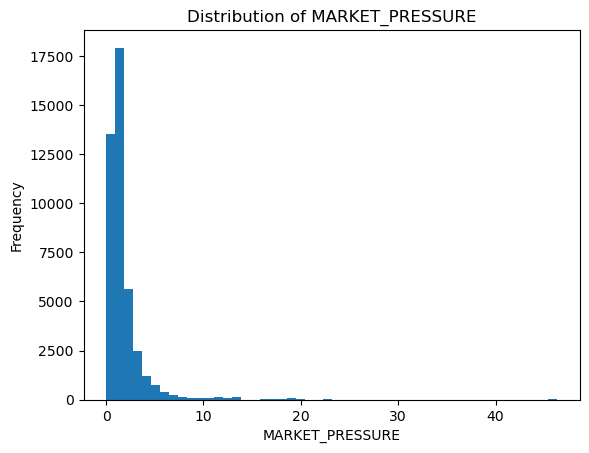

In [16]:
# Distribution of MARKET_PRESSURE
plt.figure()
plt.hist(sales_df["MARKET_PRESSURE"].dropna(), bins=50)
plt.title("Distribution of MARKET_PRESSURE")
plt.xlabel("MARKET_PRESSURE")
plt.ylabel("Frequency")
plt.show()

This measures listing price relative to overall market conditions to capture competitive positioning.

#### Negotiation Features

In [17]:
# Negotiation Gap

sales_df["NEGOTIATION_GAP"] = (
    sales_df["LIST_PRICE"] - sales_df["OFFER_PRICE"]
)


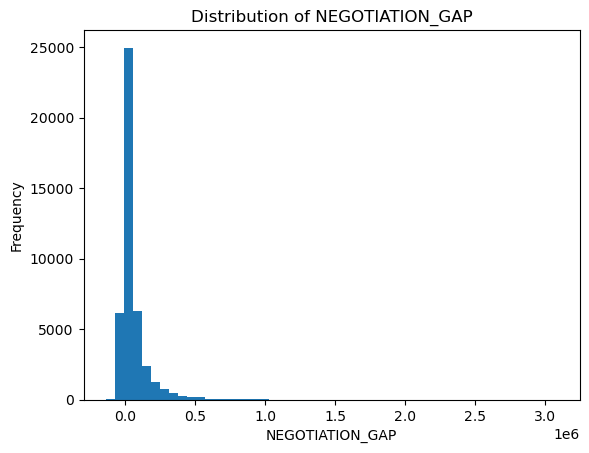

In [18]:

# 2️⃣ Distribution of NEGOTIATION_GAP
plt.figure()
plt.hist(sales_df["NEGOTIATION_GAP"].dropna(), bins=50)
plt.title("Distribution of NEGOTIATION_GAP")
plt.xlabel("NEGOTIATION_GAP")
plt.ylabel("Frequency")
plt.show()

This captures buyer aggressiveness and negotiation dynamics impacting final sale price.

#### Location Based Features

In [19]:
# zip_counts

zip_counts = sales_df["ZIPCODE"].value_counts()
sales_df["ZIP_ACTIVITY"] = sales_df["ZIPCODE"].map(zip_counts)


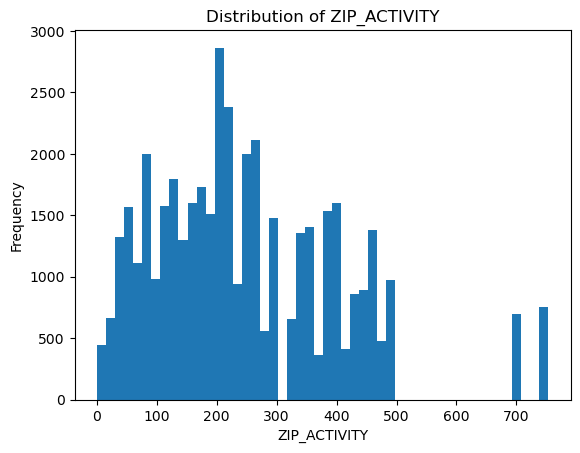

In [20]:
# Distribution of ZIP_ACTIVITY
plt.figure()
plt.hist(sales_df["ZIP_ACTIVITY"].dropna(), bins=50)
plt.title("Distribution of ZIP_ACTIVITY")
plt.xlabel("ZIP_ACTIVITY")
plt.ylabel("Frequency")
plt.show()

The puporse of this is to capture area-level demand intensity and tranformation activity.

#### Target Transformation

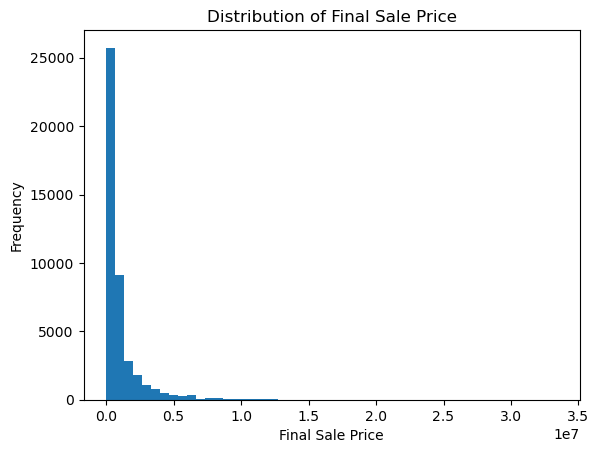

In [21]:
# Histogram to visualise Final_Sale_Price

plt.figure()
plt.hist(sales_df["FINAL_SALE_PRICE"], bins=50)
plt.title("Distribution of Final Sale Price")
plt.xlabel("Final Sale Price")
plt.ylabel("Frequency")
plt.show()

The final Sale Price Distribution is extremely right skewed, with most properties clustered at lower ranges and a small number of very expensive properties which stretch the tail to the far right. 
- This dataset contains normal residential homes and some high end/ luxury properties

In [22]:
# Log Transform Target

sales_df["LOG_FINAL_SALE_PRICE"] = np.log1p(
    sales_df["FINAL_SALE_PRICE"]
)

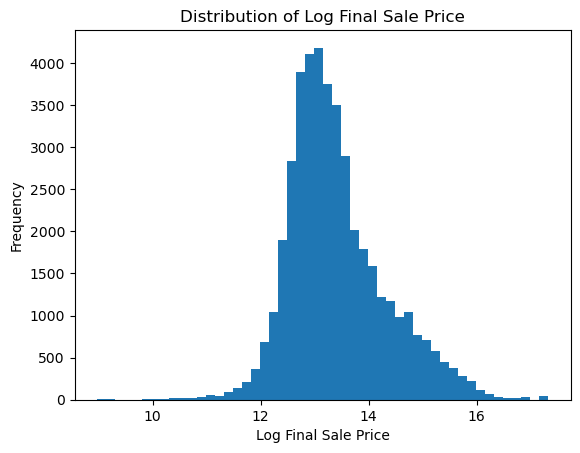

In [23]:
# Histogram to visualise log transformed Final Sale Price

plt.figure()
plt.hist(sales_df["LOG_FINAL_SALE_PRICE"], bins=50)
plt.title("Distribution of Log Final Sale Price")
plt.xlabel("Log Final Sale Price")
plt.ylabel("Frequency")
plt.show()

The log Final Sale Price shows a reduction in the skewnes. The skew has been reduced to near-normal distribution. This has reduced the influence of luxury outliers.
- The original sale price distribution was highly skewed. Log transformation stabilizes variance, reduces the impact of extreme values, and improves predictive performance and generalization.

#### Remove Outliers from Negotiation Gap and Market Pressure

In [32]:
def cap_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[column + "_CAPPED"] = df[column].clip(lower_bound, upper_bound)
    
    print(f"{column}")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Values capped: {(df[column] < lower_bound).sum() + (df[column] > upper_bound).sum()}")
    
    return df

In [33]:
sales_df = cap_outliers_iqr(sales_df, "NEGOTIATION_GAP")
sales_df = cap_outliers_iqr(sales_df, "MARKET_PRESSURE")

NEGOTIATION_GAP
Lower bound: -97450.0
Upper bound: 160550.0
Values capped: 4222
MARKET_PRESSURE
Lower bound: -0.8279570085636014
Upper bound: 3.645938726361086
Values capped: 3806


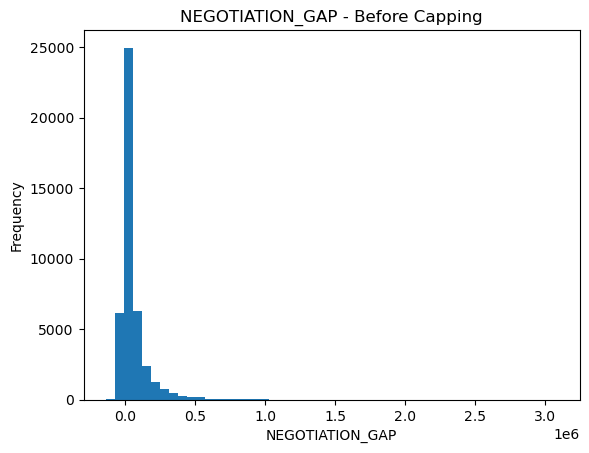

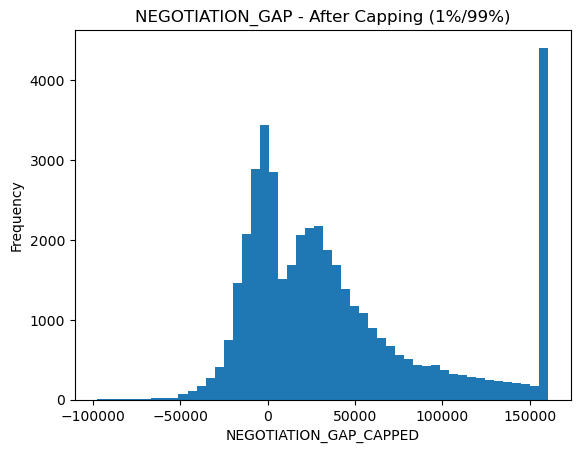

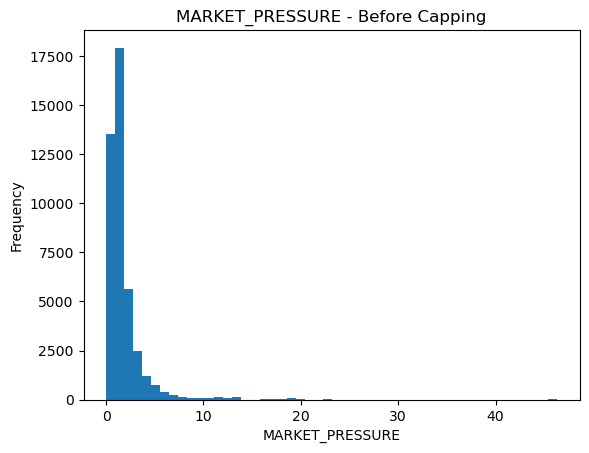

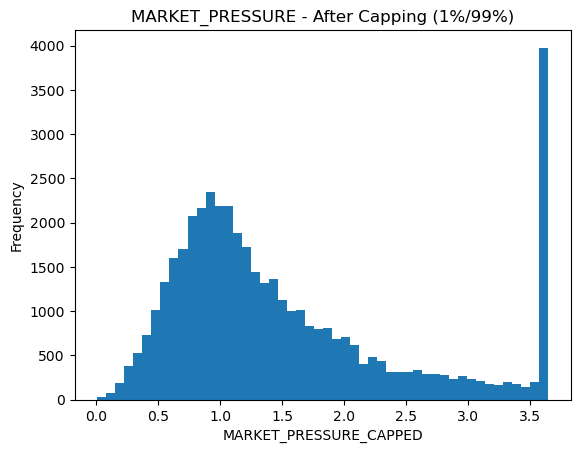

In [35]:

# NEGOTIATION GAP - BEFORE

plt.figure()
plt.hist(sales_df["NEGOTIATION_GAP"].dropna(), bins=50)
plt.title("NEGOTIATION_GAP - Before Capping")
plt.xlabel("NEGOTIATION_GAP")
plt.ylabel("Frequency")
plt.show()

# NEGOTIATION GAP - AFTER

plt.figure()
plt.hist(sales_df["NEGOTIATION_GAP_CAPPED"].dropna(), bins=50)
plt.title("NEGOTIATION_GAP - After Capping (1%/99%)")
plt.xlabel("NEGOTIATION_GAP_CAPPED")
plt.ylabel("Frequency")
plt.show()

# MARKET PRESSURE - BEFORE

plt.figure()
plt.hist(sales_df["MARKET_PRESSURE"].dropna(), bins=50)
plt.title("MARKET_PRESSURE - Before Capping")
plt.xlabel("MARKET_PRESSURE")
plt.ylabel("Frequency")
plt.show()

# MARKET PRESSURE - AFTER

plt.figure()
plt.hist(sales_df["MARKET_PRESSURE_CAPPED"].dropna(), bins=50)
plt.title("MARKET_PRESSURE - After Capping (1%/99%)")
plt.xlabel("MARKET_PRESSURE_CAPPED")
plt.ylabel("Frequency")
plt.show()

Extreme values were identified in the Market_Pressure and Negotiation Gap data which could distort the model’s learning. Rather than removing valid transactions, we limited only the top and bottom 1% of extreme cases to stabilize the model while preserving all data. This improves prediction accuracy and reliability.

#### Relationship Check

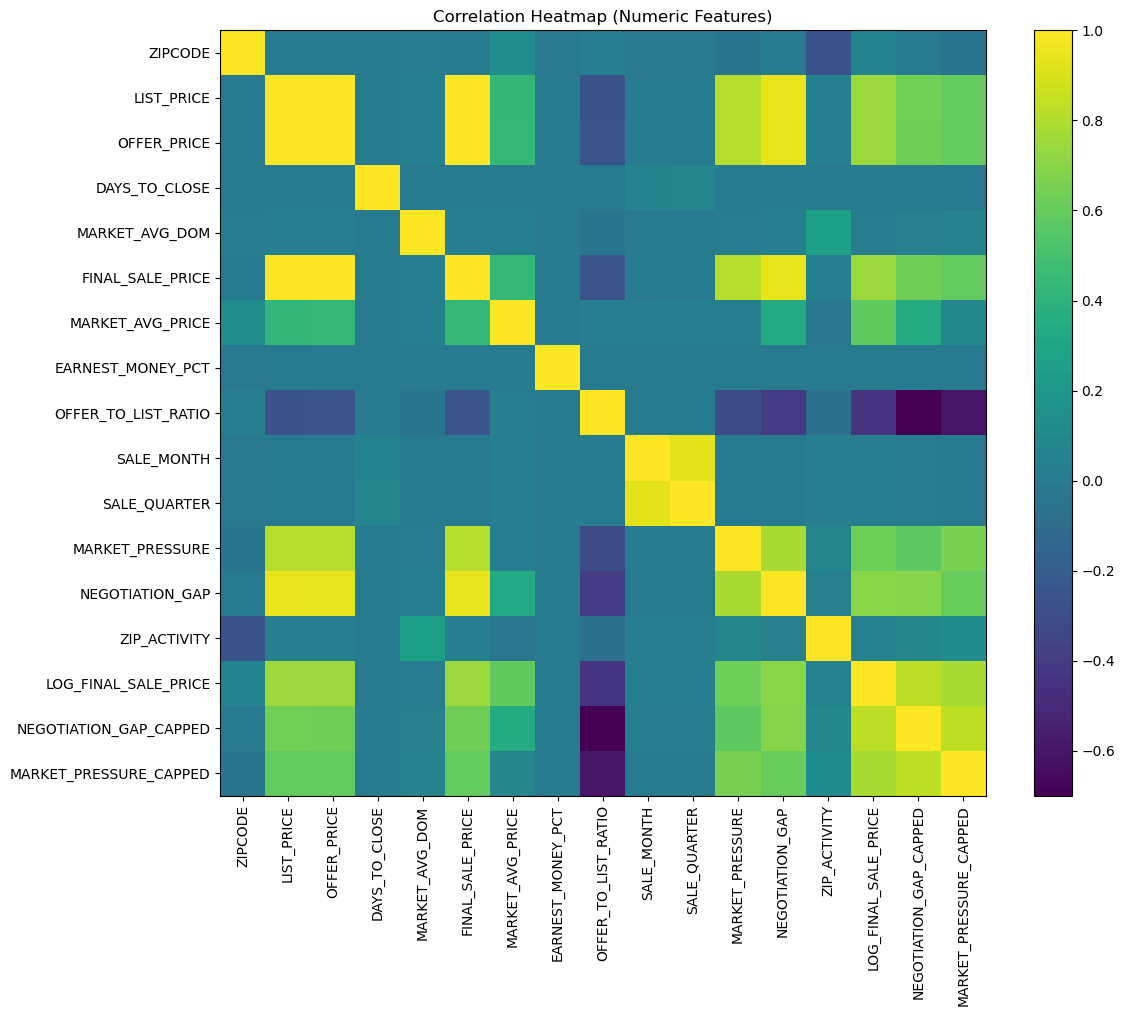

In [43]:
# Correlation heatmap

numeric_df = sales_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12, 10))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap (Numeric Features)")
plt.colorbar()
plt.tight_layout()
plt.show()

The correlation heatmap shows that:

List Price is the strongest predictor of Final Sale Price.

Offer Price and Negotiation-related features also show strong relationships with final pricing.

Engineered features such as Market Pressure and Negotiation Gap add meaningful predictive signal.

Area-level variables (e.g., Market Average Price, ZIP Activity) moderately influence final pricing.

Some operational variables (e.g., Days to Close, Seasonality) show weaker linear relationships but may still contribute in advanced models.
The heatmap confirms that: 
- Data integrity appears strong
- No unexpected correlations
- Feature engineering added meaningful signal
-  No obvious data leakage
- Strong market-driven structure in pricing

## Select Features for the Model

In [52]:
feature_cols = [
    "LIST_PRICE",
    "OFFER_PRICE",
    "OFFER_TO_LIST_RATIO",
    "NEGOTIATION_GAP_CAPPED",
    "MARKET_PRESSURE_CAPPED",
    "ZIP_ACTIVITY",
    "SALE_MONTH",
    "SALE_QUARTER",
    "PROPERTY_TYPE",
    "FINANCING_TYPE",
]

feature_cols = [c for c in feature_cols if c in sales_df.columns]

model_df = sales_df[feature_cols + ["LOG_FINAL_SALE_PRICE"]].copy()
model_df = model_df.dropna(subset=["LOG_FINAL_SALE_PRICE"])

print("Model df shape:", model_df.shape)

Model df shape: (43304, 11)
